# Hierarchical Classification of Threatened Mammals Relevant to Singapore

## 1. Defining the Problem & Assembling a Dataset

### 1.1 Problem Context & Motivation

Monitoring wildlife populations is important for understanding biodiversity change & informing conservation decisions. Traditional wildlife-monitoring methods include direct field surveys, transects, indirect evidence such as nests or scat, & camera traps. Although these approaches provide valuable ecological data, biodiversity observations remain geographically uneven & taxonomically biased.

Previous research has highlighted that biodiversity information is often spatially patchy & that monitoring effort is not distributed equally between regions or taxonomic groups. Hughes et al. (2021), for example, discuss geographic sampling biases in major biodiversity databases, while Titley, Snaddon & Turner (2017) found that animal biodiversity research was disproportionately concentrated on vertebrates & temperate or economically developed regions. Other work has also highlighted uncertainty caused by uneven temporal & geographic coverage of biodiversity observations.

Camera traps can reduce the need for continuous human presence in the field & allow wildlife to be recorded remotely. However, they may generate large quantities of photographs that subsequently require identification. Manual review therefore creates another potential bottleneck in the monitoring workflow.

Image classification offers a way to assist this stage. Rather than replacing ecological population-estimation methods, a neural-network classifier can support researchers by automatically assigning likely taxonomic labels to wildlife photographs. This could reduce the amount of manual image screening required & make larger image collections more practical to analyse.

This project investigates this problem using threatened mammal species relevant to Singapore. Because sufficient Singapore-only observations were unavailable for several selected species, training imagery was obtained from the broader Southeast Asian region using iNaturalist.

### 1.2 Research Question

To what extent can a hierarchical neural-network system restricted to Dense & Dropout layers distinguish selected threatened mammal taxa relevant to Singapore from real-world iNaturalist images, & what limitations arise from class imbalance, limited data & the use of flattened image representations?

### 1.3 Objectives

The objectives of this project are to:

1. construct a reproducible image dataset for selected threatened mammal species relevant to Singapore;
2. preprocess the images into a representation compatible with Dense neural networks;
3. investigate the effects of class weighting, dropout, learning rate & activation function;
4. develop a hierarchical classifier across order, family & species levels;
5. evaluate model behaviour using accuracy, macro F1 score, confusion matrices & learning curves; &
6. identify the main limitations affecting classification performance.

### 1.4 Biodiversity Monitoring Challenges

Wildlife observation data are not a complete inventory of biodiversity. Monitoring effort varies considerably between locations, species groups & time periods, which can influence conclusions drawn from biodiversity datasets.

Gonzalez et al. (2016) criticised limitations in the spatial coverage of studies used to estimate local biodiversity change, while Leung et al. (2020) discussed uncertainty in global vertebrate trends arising from the distribution of available monitoring data.

Hughes et al. (2021) further showed that biodiversity occurrence records are affected by substantial sampling biases. Even large biodiversity databases provide much denser coverage in some regions than others.

Taxonomic bias is also important. Titley, Snaddon & Turner (2017) found that biodiversity research was disproportionately focused on vertebrates despite invertebrates representing the majority of described animal diversity. Their study also identified geographical bias, with substantially more biodiversity research conducted in temperate & economically developed regions than in many tropical areas.

Remote image collection can also reduce the amount of continuous direct human presence required in wildlife habitats, although field deployment & ecological survey design remain necessary.

These limitations do not mean automated image classification can solve biodiversity-monitoring bias by itself. However, tools that reduce the effort required to process wildlife photographs may make larger image datasets easier to analyse & can therefore contribute to more scalable monitoring workflows.

### 1.5 Data Source: iNaturalist

iNaturalist was selected because it provides a large collection of real-world biodiversity observations together with taxonomic information & openly licensed photographs. The iNaturalist API makes the data-acquisition procedure repeatable, but live API results may change over time as observations are added, removed or re-identified. Therefore, the processed NumPy arrays were saved & reused as a fixed dataset snapshot for the modelling experiments.

The photographs also represent realistic classification conditions rather than controlled laboratory images. Images can vary in background, scale, orientation, illumination, distance & image quality. This makes the resulting classification problem challenging but more representative of wildlife-observation imagery.

Only observations containing usable photographs were retained. Where more than 100 usable images were available for a species, the dataset was capped at approximately 100 images to reduce extreme dominance by highly represented species.

### 1.6 Selected Taxa & Conservation Context

Species observations, taxon identifiers & image data were obtained from iNaturalist.
Singapore conservation statuses were taken separately from the NParks terrestrial mammal list, which reports the Singapore Red Data Book (RDB3) classifications.

The selected taxa were chosen from mammals of conservation relevance to Singapore. Because the number of locally photographed observations was insufficient for several species, image acquisition was broadened to Southeast Asia while retaining species that are relevant to Singapore conservation.

Although this improves sample availability, it also means the dataset does not represent Singapore-specific photographic conditions, habitats or observation patterns exclusively.

| Species | Scientific name | Family | Order | Singapore Red List (RDB3) status |
|---|---|---|---|---|
| Sunda Pangolin | *Manis javanica* | Manidae | Pholidota | CR |
| Red Giant Flying Squirrel | *Petaurista petaurista* | Sciuridae | Rodentia | CR |
| East Asian/Malayan Porcupine | *Hystrix brachyura* | Hystricidae | Rodentia | CR |
| Mainland Leopard Cat | *Prionailurus bengalensis* | Felidae | Carnivora | CR |
| Small-tooth Palm Civet | *Arctogalidia trivirgata* | Viverridae | Carnivora | CR |
| Masked Palm Civet | *Paguma larvata* | Viverridae | Carnivora | CR |
| Large Indian Civet | *Viverra zibetha* | Viverridae | Carnivora | CR |
| Asian Small-clawed Otter | *Aonyx cinereus* | Mustelidae | Carnivora | CR |
| Smooth-coated Otter | *Lutrogale perspicillata* | Mustelidae | Carnivora | EN |

The final processed dataset contained 731 usable images. The order-level distribution was:

| Order | Images |
|---|---:|
| Pholidota | 99 |
| Rodentia | 140 |
| Carnivora | 492 |
| **Total** | **731** |

The strong imbalance between Carnivora & the two smaller orders motivated the use of class weighting & macro F1 during model development.

The acquisition process included observations from multiple iNaturalist quality grades in order to increase the amount of usable data. While this improves sample availability, it may also introduce additional taxonomic label noise compared with using only research-grade observations.

This project follows the universal machine-learning workflow described by Chollet (2018), progressing from problem definition & dataset assembly through metric selection, evaluation design, data preparation, baseline development, overfitting analysis, regularisation & hyperparameter tuning, before final evaluation on held-out test data.

### Intended Classification Workflow

This project follows the universal machine-learning workflow described by Chollet (2018), progressing from problem definition & dataset assembly through metric selection, evaluation design, data preparation, baseline development, overfitting analysis, regularisation & hyperparameter tuning, before final evaluation on held-out test data.

Wildlife image  
↓  
Image preprocessing  
↓  
Neural network classifier  
↓  
Taxonomic prediction  
↓  
Predicted species / taxonomic group

## 2. Choosing a Measure of Success

Because the dataset is imbalanced, accuracy alone is insufficient as the primary measure of performance. Macro F1 is therefore used as the main model-selection metric because it assigns equal importance to every class regardless of class frequency. Accuracy, per-class precision & recall, confusion matrices & learning curves are used as supporting measures.

The objective is not to achieve a predetermined accuracy threshold, but to produce a well-validated model whose behaviour is understood & whose limitations can be explained.

## 3. Deciding on an Evaluation Protocol

### 3.1 Training, Validation & Test Split

The 731 processed images were divided into approximately 70% training, 15% validation & 15% test data.

The split was stratified by class so that each subset retained approximately the same class proportions as the complete dataset. This is important because a purely random split could produce validation or test sets with very few minority-class examples.

The validation set was used for model comparison & hyperparameter decisions. The test set was kept separate from model development & was evaluated only after the final configurations had been selected.

Although camera traps provide one important source of wildlife imagery, the present experiment uses photographs obtained from iNaturalist rather than a dedicated camera-trap dataset. The trained system should therefore be interpreted as a proof of concept for automated wildlife-image classification rather than a validated camera-trap deployment system.

## 4. Preparing the Data

### 4.1 Imports & Configurations 

In [1]:
# import necessary libraries/dependencies 
import matplotlib.pyplot as plt
import numpy as np
import os
import urllib.request
import PIL
from PIL import Image, ImageOps
from io import BytesIO
# import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight
import pathlib
import requests

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

Reproducibility was controlled using tf.keras.utils.set_random_seed(42), which sets the Python, NumPy & TensorFlow random seeds, together with deterministic TensorFlow operations (TensorFlow Developers, 2026).

In [2]:
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

### 4.2 Image Acquisition

In [3]:
# list of dictionaries for the species
# taxon id -- conservation status -- species -- scientific name -- family -- order

species_list = [
                    {
                        "species_name": "sunda pangolin",
                        "scientific_name": "manis javanica",
                        "animal_family": "manidae",
                        "animal_order": "pholidota",
                        "taxon_id": 43364,
                        "conservation_status": "CR",
                        "usable_count": 108
                    },
                    {
                        "species_name": "red giant flying squirrel",
                        "scientific_name": "petaurista petaurista",
                        "animal_family": "sciuridae",
                        "animal_order": "rodentia",
                        "taxon_id": 45982,
                        "conservation_status": "CR",
                        "usable_count": 39
                    },
                    {
                        "species_name": "east asian/malayan porcupine",
                        "scientific_name": "hystrix brachyura",
                        "animal_family": "hystricidae",
                        "animal_order": "rodentia",
                        "taxon_id": 44172,
                        "conservation_status": "CR",
                        "usable_count": 422
                    },
                    {
                        "species_name": "mainland leopard cat",
                        "scientific_name": "prionailurus bengalensis",
                        "animal_family": "felidae",
                        "animal_order": "carnivora",
                        "taxon_id": 922738,
                        "conservation_status": "CR",
                        "usable_count": 156 
                    },
                    {
                        "species_name": "small-tooth palm civet",
                        "scientific_name": "arctogalidia trivirgata",
                        "animal_family": "viverridae",
                        "animal_order": "carnivora",
                        "taxon_id": 41602,
                        "conservation_status": "CR",
                        "usable_count": 82  
                    },
                    {
                        "species_name": "masked palm civet",
                        "scientific_name": "paguma larvata",
                        "animal_family": "viverridae",
                        "animal_order": "carnivora",
                        "taxon_id": 41625,
                        "conservation_status": "CR",
                        "usable_count": 80  
                    },
                    {
                        "species_name": "large indian civet",
                        "scientific_name": "viverra zibetha",
                        "animal_family": "viverridae",
                        "animal_order": "carnivora",
                        "taxon_id": 41613,
                        "conservation_status": "CR",
                        "usable_count": 40  
                    },
                    {
                        "species_name": "asian small-clawed otter",
                        "scientific_name": "lutra cinerea",
                        "animal_family": "mustelidae",
                        "animal_order": "carnivora",
                        "taxon_id": 1638835,
                        "conservation_status": "CR",
                        "usable_count": 90  
                    },
                    {
                        "species_name": "smooth-coated otter",
                        "scientific_name": "lutrogale perspicillata",
                        "animal_family": "mustelidae",
                        "animal_order": "carnivora",
                        "taxon_id": 1638842,
                        "conservation_status": "EN",
                        "usable_count": 1835  
                    }
                ]

for animal in species_list:
    print(animal["species_name"], animal["usable_count"])

sunda pangolin 108
red giant flying squirrel 39
east asian/malayan porcupine 422
mainland leopard cat 156
small-tooth palm civet 82
masked palm civet 80
large indian civet 40
asian small-clawed otter 90
smooth-coated otter 1835


`usable_count` refers to the approximate number of qualifying observations found during preliminary dataset exploration. The final training dataset was capped at approximately 100 images per species where available, so these counts are not the final numbers used for model training.

### 4.3 Resizing & Padding

In [4]:
# resize & convert image to 80 x 80, rgb
def resize_photo(images):
    images = images.convert("RGB")
    target_size = (80, 80)

    padded_imgs = ImageOps.pad(images, 
                              target_size, 
                              color = "white", 
                              centering = (0.5, 0.5))

    return padded_imgs

Images were resized to 80 × 80 using aspect-ratio-preserving padding rather than direct stretching. This avoids distorting the animal's proportions while still producing a fixed input size for the neural network.

An image size of 80 × 80 was chosen as a practical compromise between retaining basic visual information & limiting the dimensionality of the flattened Dense-network input.

Image conversion, resizing & aspect-ratio-preserving padding were implemented using the Pillow image-processing library, particularly Image.convert() & ImageOps.pad() (Pillow Contributors, 2026).

### 4.4 Image Preprocessing

NumPy was used throughout preprocessing for image-array conversion, datatype handling, flattening, label arrays, filtering & numerical operations (NumPy Developers, 2026).

In [5]:
# convert images to arrays
def img_to_arr(padded_imgs):
    imgs_arr = np.array(padded_imgs)
    return imgs_arr

### 4.5 Normalisation & Flattening

In [6]:
# normalise images to [0, 1]
def normal_img(imgs_arr):
    imgs_arr = imgs_arr.astype("float32")
    imgs_arr /= 255.0

    return imgs_arr

In [7]:
# flatten 3D tensor into a 1D tensor
def flatten_arr(imgs_arr):
    flattened_arrs = imgs_arr.flatten()

    return flattened_arrs

### 4.6 Final Preprocessing, Label Encoding & Final Arrays

Wildlife observation metadata was retrieved using the iNaturalist API v2. HTTP requests & JSON responses were handled using the Python Requests library (iNaturalist, 2026; Requests Developers, 2026).

In [8]:
# tag a number to an animal order
int_to_order = {
    0: "pholidota",
    1: "rodentia",
    2: "carnivora"
}

# tag an animal order to the numbers in int_to_order
order_to_int = {
    v: k for k, v in int_to_order.items()
}

family_to_int = {
    "manidae": 0,
    "sciuridae": 1,
    "hystricidae": 2,
    "felidae": 3,
    "viverridae": 4,
    "mustelidae": 5
}

species_to_int = {
    "sunda pangolin": 0,
    "red giant flying squirrel": 1,
    "east asian/malayan porcupine": 2,
    "mainland leopard cat": 3,
    "small-tooth palm civet": 4,
    "masked palm civet": 5,
    "large indian civet": 6,
    "asian small-clawed otter": 7,
    "smooth-coated otter": 8
}

In [9]:
# set to false for modelling & final submission run
REBUILD_DATASET = False

In [10]:
# API request with dict key
def req_api(animal):
    page_index = 1 # first page is 1, not 0
    collected_obs = [] # for collecting observations
    max_obs = 100 # max. number of observations to collect
    
    url = (
        "https://api.inaturalist.org/v2/observations?"
        "place_id=57241,162124"
        "&photos=true"
        "&quality_grade=needs_id,research,casual"
        "&photo_license=cc0,cc-by,cc-by-nc"
        "&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
    )

    # while the no. of collected observations is lesser than delcared max.
    while len(collected_obs) < max_obs:
        query_params = {
            "taxon_id": animal["taxon_id"], 
            "page": page_index
        } 
        
        # GET request to URL
        response = requests.get(url, params = query_params, timeout = 30)
        data = response.json()
        
        page_results = data["results"]

        if not page_results: # no more available observations on page
            break

        collected_obs += page_results # append observation (results) into empty list

        print(
            "Page Number:", page_index,
             "| Retrieved:", len(page_results),
             "| Total Observations Collected:", len(collected_obs)
             )
        
        page_index += 1 # go to the next page

    trim_obs = collected_obs[:max_obs] # trim total no. of observations collected to previously set max.

    print(
        "Animal:", animal["species_name"],
        "| Final Observations:", len(trim_obs)
    )
    return trim_obs

In [11]:
if REBUILD_DATASET:

    # empty lists for collected image features and labels
    x_order = []
    y_order = []
    y_family = []
    y_species = []

    for animal in species_list:
        animal_info = req_api(animal)
        observations = animal_info

        animal_order = animal["animal_order"]

        order_int = order_to_int[animal_order]
        family_int = family_to_int[animal["animal_family"]]
        species_int = species_to_int[animal["species_name"]]

        print(
            "\nProcessing:", animal["species_name"],
            "| Images:", len(observations),
            "| Order:", order_int
        )

        for observation in observations:

            if not observation["photos"]:
                continue

            photo_info = observation["photos"][0]

            if "url" not in photo_info:
                continue

            new_url = photo_info["url"].replace(
                "square",
                "medium"
            )

            try:
                img_response = requests.get(
                    new_url,
                    timeout = 30
                )

                if img_response.status_code != 200:
                    continue

                images = Image.open(
                    BytesIO(img_response.content)
                )

                rs_observation = resize_photo(images)
                obs_arr = img_to_arr(rs_observation)
                normalised = normal_img(obs_arr)
                flat = flatten_arr(normalised)

                if flat.shape != (19200,):
                    continue

                x_order.append(flat)
                y_order.append(order_int)
                y_family.append(family_int)
                y_species.append(species_int)

            except Exception as e:
                print("Skipped Image:", e)


    # Convert lists to NumPy arrays
    x_order_arr = np.array(
        x_order,
        dtype = "float32"
    )

    y_order_arr = np.array(
        y_order,
        dtype = "int32"
    )

    y_family_arr = np.array(
        y_family,
        dtype = "int32"
    )

    y_species_arr = np.array(
        y_species,
        dtype = "int32"
    )

    print("\nFinal Order Dataset")
    print("X:", x_order_arr.shape)
    print("Order:", y_order_arr.shape)
    print("Family:", y_family_arr.shape)
    print("Species:", y_species_arr.shape)

    print(
        "Pholidota:", np.sum(y_order_arr == 0),
        "Rodentia:", np.sum(y_order_arr == 1),
        "Carnivora:", np.sum(y_order_arr == 2)
    )

    assert (
        len(x_order_arr)
        == len(y_order_arr)
        == len(y_family_arr)
        == len(y_species_arr)
    )

    print("All input & label arrays are aligned")

    # Save the new fixed snapshot
    np.save("data/x_order_arr.npy", x_order_arr)
    np.save("data/y_order_arr.npy", y_order_arr)
    np.save("data/y_family_arr.npy", y_family_arr)
    np.save("data/y_species_arr.npy", y_species_arr)

    print("Dataset snapshot saved.")

else:
    print("Dataset rebuild skipped. Existing saved snapshot will be used.")

Dataset rebuild skipped. Existing saved snapshot will be used.


The final processed dataset contained 731 images rather than the maximum possible capped total because some species had fewer than 100 available observations, while a small number of downloaded images were skipped when they could not be successfully loaded or processed.

The processed dataset was saved & reloaded as NumPy .npy arrays using NumPy's array persistence functions to provide a fixed experimental snapshot (NumPy Developers, 2026).

In [12]:
# load fixed dataset snapshot for modelling

x_order_arr = np.load("data/x_order_arr.npy")
y_order_arr = np.load("data/y_order_arr.npy")
y_family_arr = np.load("data/y_family_arr.npy")
y_species_arr = np.load("data/y_species_arr.npy")

print("Loaded fixed dataset snapshot")
print("X:", x_order_arr.shape)
print("Order:", y_order_arr.shape)
print("Family:", y_family_arr.shape)
print("Species:", y_species_arr.shape)

Loaded fixed dataset snapshot
X: (731, 19200)
Order: (731,)
Family: (731,)
Species: (731,)


Stratified training, validation & test splits were implemented using scikit-learn's train_test_split() utility. A fixed random_state was used to support reproducibility (scikit-learn Developers, 2026).

In [13]:
# splitting dataset for training / testing

x_train, x_temp, y_train, y_temp = train_test_split(x_order_arr, 
                                                    y_order_arr, 
                                                    test_size = 0.3, 
                                                    stratify = y_order_arr,
                                                    random_state = 42)

x_val, x_test, y_val, y_test = train_test_split(x_temp, 
                                                y_temp, 
                                                test_size = 0.5, 
                                                stratify = y_temp,
                                                random_state = 42)

In [14]:
# no. of samples in each set
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(511, 19200)
(110, 19200)
(110, 19200)


Balanced class weights were calculated using scikit-learn's compute_class_weight() function to reduce the influence of class imbalance during model training (scikit-learn Developers, 2026).

In [15]:
# estimate class weights (dataset is unbalanced)
data_balance = compute_class_weight(
                    class_weight = "balanced", 
                    classes = np.unique(y_train), 
                    y = y_train
                )
print(data_balance)

[2.46859903 1.73809524 0.49515504]


In [16]:
classes = np.unique(y_train)

db_results = {int(k): float(v) for k, v in zip(classes, data_balance)}
print(db_results)

{0: 2.468599033816425, 1: 1.7380952380952381, 2: 0.4951550387596899}


## 5. Developing a Model That Does Better Than a Baseline

The first modelling objective was to determine whether a Dense neural network could learn useful predictive information from the flattened image representation.

A simple Order classifier was trained as the initial baseline & evaluated using validation accuracy, macro F1, per-class precision & recall.

Neural-network models were implemented using the TensorFlow/Keras Sequential API with Dense & Dropout layers, in accordance with the layer restrictions of the assignment. The overall model-development procedure follows the workflow introduced by Chollet (2018), while implementation uses the TensorFlow/Keras API (Chollet, 2018; TensorFlow Developers, 2026).

In [17]:
# ML model
model = tf.keras.Sequential([
    keras.Input(shape = (19200, )),
    layers.Dense(64, activation = "relu"),
    layers.Dropout(0.5),
    layers.Dense(3, activation = "softmax")
])

# compile model
model.compile(
    optimizer = keras.optimizers.AdamW(),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
    # metrics = metrics_list
)

# fit model
model.fit(
    x = x_train,
    y = y_train,
    batch_size = 16,
    epochs = 50,
    validation_data = (x_val, y_val),
    verbose = 0
)

Sparse categorical cross-entropy & sparse categorical accuracy were implemented using the corresponding TensorFlow/Keras loss and metric APIs. AdamW was used as the optimiser through keras.optimizers.AdamW (TensorFlow Developers, 2026).

Models were trained using the Keras Model.fit() interface with validation data & class weights supplied during fitting (TensorFlow Developers, 2026).

In [18]:
# test to see if the model is predicting that all animals are in the carnivora order (index 2)
x_val2 = model.predict(x_val)
print(x_val2.shape)

pred_check = np.argmax(x_val2, axis = 1)
print(np.unique(pred_check, return_counts = True))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
(110, 3)
(array([2]), array([110]))


Class probabilities were generated using the Keras prediction API & converted to predicted class indices using NumPy's argmax() operation (TensorFlow Developers, 2026; NumPy Developers, 2026).

Classification reports, macro F1 scores & confusion matrices were produced using scikit-learn's model-evaluation utilities, including classification_report(), f1_score(), confusion_matrix() & ConfusionMatrixDisplay (scikit-learn Developers, 2026).

Training & validation learning curves were visualised using Matplotlib (Matplotlib Development Team, 2026).

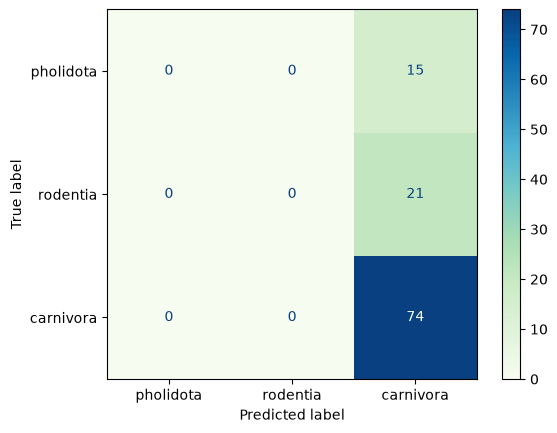

In [19]:
# build confusion matrix
y_pred = np.argmax(x_val2, axis = 1)
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["pholidota", "rodentia", "carnivora"])
disp.plot(cmap = "GnBu")
plt.show()

Precision, recall, F1 scores & macro F1 were calculated using scikit-learn's classification metrics (scikit-learn Developers, 2026).

In [20]:
# classification report
classification_report(y_val, y_pred, zero_division = 0, output_dict = True)

{'0': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 15.0},
 '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 21.0},
 '2': {'precision': 0.6727272727272727,
  'recall': 1.0,
  'f1-score': 0.8043478260869565,
  'support': 74.0},
 'accuracy': 0.6727272727272727,
 'macro avg': {'precision': 0.22424242424242424,
  'recall': 0.3333333333333333,
  'f1-score': 0.26811594202898553,
  'support': 110.0},
 'weighted avg': {'precision': 0.4525619834710744,
  'recall': 0.6727272727272727,
  'f1-score': 0.5411067193675889,
  'support': 110.0}}

### Loss Function & Output Layer

Sparse categorical cross-entropy was used because the target classes are stored as integer labels rather than one-hot encoded vectors.

A softmax activation was used in the output layer so that each classifier produces a probability distribution across the mutually exclusive classes in that branch.

AdamW was used consistently as the optimiser throughout the final experiments. Keeping the optimiser fixed allowed the investigation to focus on the effects of class weighting, dropout, learning rate & activation function.

| Component | Configuration |
|---|---|
| Input | 19,200 flattened RGB values |
| Hidden layer | Dense, 64 units, tanh |
| Regularisation | Dropout 0.1 |
| Output | Softmax |
| Optimiser | AdamW |
| Learning rate | 1e-4 |
| Loss | Sparse categorical cross-entropy |
| Batch size | 16 |
| Epochs | 50 |


The same general architecture was used for the hierarchical branch classifiers, with the number of output units adjusted to match the number of classes in each branch.

## 6. Scaling Up: Developing a Model That Overfits

Following the universal workflow, the next objective was to test whether increasing the model's ability to fit the training data would expose overfitting.

The initial model used a dropout rate of 0.5. To reduce regularisation, dropout was lowered & the resulting training and validation behaviour was examined. The intention was to determine whether the model could fit the training data more strongly before later applying regularisation and tuning.

However, the resulting configurations did not show a clean pattern of conventional overfitting. Instead, some models became unstable and collapsed towards predicting a single class. This indicated that optimisation & class imbalance were also limiting learning, rather than model capacity alone.

These results motivated the next stage of experimentation with class weighting, learning rate and activation function.

In [21]:
# new model but changed dropout
# ML model
f_model = tf.keras.Sequential([
    keras.Input(shape = (19200, )),
    layers.Dense(64, activation = "relu"),
    layers.Dropout(0.1),
    layers.Dense(3, activation = "softmax")
])

# compile model
f_model.compile(
    optimizer = keras.optimizers.AdamW(),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
    # metrics = metrics_list
)

f_model_hist = f_model.fit(
                    x = x_train,
                    y = y_train,
                    batch_size = 16,
                    epochs = 50,
                    validation_data = (x_val, y_val),
                    class_weight = db_results,
                    verbose = 0
                )

In [22]:
# test to see if the model is predicting that all animals are in the carnivora order (index 2)
x_val2 = f_model.predict(x_val)
print(x_val2.shape)

pred_check = np.argmax(x_val2, axis = 1)
print(np.unique(pred_check, return_counts = True))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
(110, 3)
(array([0]), array([110]))


In [23]:
# check first 5 values
print(x_val2[:5])

[[0.3337776  0.33322835 0.33299407]
 [0.3337776  0.33322835 0.33299407]
 [0.3337776  0.33322835 0.33299407]
 [0.3337776  0.33322835 0.33299407]
 [0.3337776  0.33322835 0.33299407]]


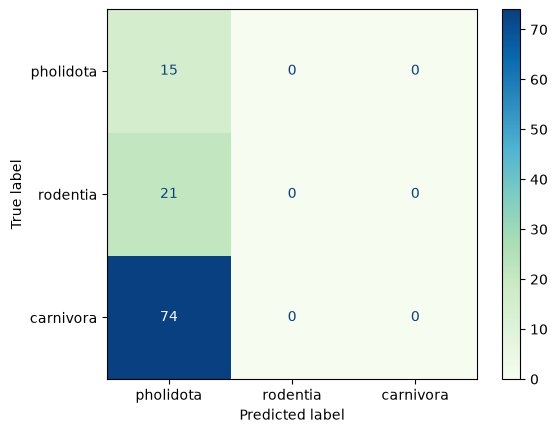

In [24]:
# build confusion matrix
y_pred = np.argmax(x_val2, axis = 1)
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["pholidota", "rodentia", "carnivora"])
disp.plot(cmap = "GnBu")
plt.show()

In [25]:
# classification report
classification_report(y_val, y_pred, zero_division = 0, output_dict = True)

{'0': {'precision': 0.13636363636363635,
  'recall': 1.0,
  'f1-score': 0.24,
  'support': 15.0},
 '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 21.0},
 '2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 74.0},
 'accuracy': 0.13636363636363635,
 'macro avg': {'precision': 0.04545454545454545,
  'recall': 0.3333333333333333,
  'f1-score': 0.08,
  'support': 110.0},
 'weighted avg': {'precision': 0.01859504132231405,
  'recall': 0.13636363636363635,
  'f1-score': 0.03272727272727272,
  'support': 110.0}}

### Dropout has been lowered to 0.1

In [26]:
# new model but changed dropout
# ML model
low_do_model = tf.keras.Sequential([
    keras.Input(shape = (19200, )),
    layers.Dense(64, activation = "relu"),
    layers.Dropout(0.1),
    layers.Dense(3, activation = "softmax")
])

# compile model
low_do_model.compile(
    optimizer = keras.optimizers.AdamW(),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
)

low_do_hist = low_do_model.fit(
                    x = x_train,
                    y = y_train,
                    batch_size = 16,
                    epochs = 50,
                    validation_data = (x_val, y_val),
                    class_weight = db_results,
                    verbose = 0
                )

In [27]:
# test to see if the model is predicting that all animals are in the carnivora order (index 2)
x_val2 = low_do_model.predict(x_val)
print(x_val2.shape)

pred_check = np.argmax(x_val2, axis = 1)
print(np.unique(pred_check, return_counts = True))

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000235F65767A0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
(110, 3)
(array([0]), array([110]))


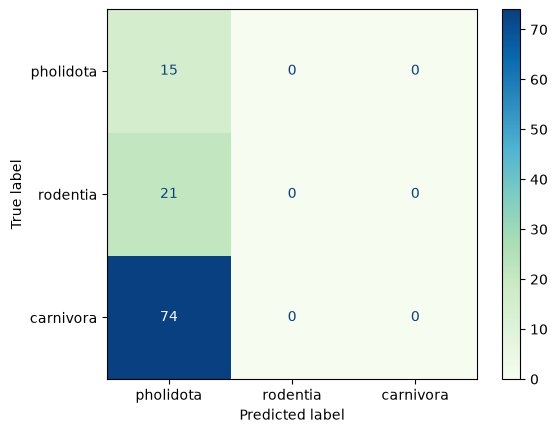

In [28]:
# build confusion matrix
y_pred = np.argmax(x_val2, axis = 1)
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["pholidota", "rodentia", "carnivora"])
disp.plot(cmap = "GnBu")
plt.show()

In [29]:
# classification report
classification_report(y_val, y_pred, zero_division = 0, output_dict = True)

{'0': {'precision': 0.13636363636363635,
  'recall': 1.0,
  'f1-score': 0.24,
  'support': 15.0},
 '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 21.0},
 '2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 74.0},
 'accuracy': 0.13636363636363635,
 'macro avg': {'precision': 0.04545454545454545,
  'recall': 0.3333333333333333,
  'f1-score': 0.08,
  'support': 110.0},
 'weighted avg': {'precision': 0.01859504132231405,
  'recall': 0.13636363636363635,
  'f1-score': 0.03272727272727272,
  'support': 110.0}}

## 7. Regularising the Model & Tuning Hyperparameters

After the scaling-up experiments exposed unstable optimisation & single-class prediction behaviour, the next stage focused on improving generalisation & training stability through regularisation & hyperparameter tuning.

The investigation examined class weighting, dropout, learning rate & activation function while retaining the Dense-only architectural constraint.

| Experiment | Class weighting | Dropout | Activation | Learning rate | Purpose |
|---|---|---:|---|---:|---|
| Baseline | No class weighting | 0.5 | ReLU | default | Initial comparison model |
| Weighted model | Yes | 0.5 | ReLU | default | Address class imbalance |
| Reduced dropout | Yes | 0.1 | ReLU | default | Test whether heavy regularisation caused underfitting |
| Reduced learning rate | Yes | 0.1 | ReLU | 1e-4 | Test whether optimisation instability caused collapse |
| Tanh model | Yes | 0.1 | tanh | 1e-4 | Test whether activation choice caused hidden-unit inactivity |

The experiments were evaluated primarily using validation macro F1, supported by minority-class recall, class-level precision & F1, prediction distributions, confusion matrices & learning curves.

In [30]:
# estimate class weights (dataset is unbalanced)
data_balance = compute_class_weight(
                    class_weight = "balanced", 
                    classes = np.unique(y_train), 
                    y = y_train
                )
print(data_balance)

[2.46859903 1.73809524 0.49515504]


In [31]:
classes = np.unique(y_train)

db_results = {int(k): float(v) for k, v in zip(classes, data_balance)}
print(db_results)

{0: 2.468599033816425, 1: 1.7380952380952381, 2: 0.4951550387596899}


In [32]:
# new model with class weights
# ML model
weighted_model = tf.keras.Sequential([
    keras.Input(shape = (19200, )),
    layers.Dense(64, activation = "relu"),
    layers.Dropout(0.5),
    layers.Dense(3, activation = "softmax")
])

# compile model
weighted_model.compile(
    optimizer = keras.optimizers.AdamW(),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
)

weighted_hist = weighted_model.fit(
                    x = x_train,
                    y = y_train,
                    batch_size = 16,
                    epochs = 50,
                    validation_data = (x_val, y_val),
                    class_weight = db_results,
                    verbose = 0
                )

In [33]:
# test to see if the model is predicting that all animals are in the carnivora order (index 2)
x_val2 = weighted_model.predict(x_val)
print(x_val2.shape)

pred_check = np.argmax(x_val2, axis = 1)
print(np.unique(pred_check, return_counts = True))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
(110, 3)
(array([0]), array([110]))


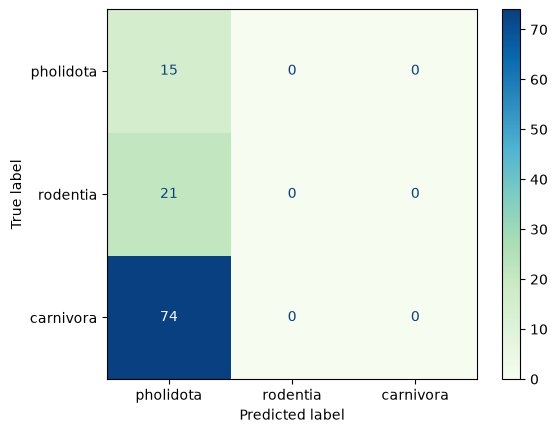

In [34]:
# build confusion matrix
y_pred = np.argmax(x_val2, axis = 1)
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["pholidota", "rodentia", "carnivora"])
disp.plot(cmap = "GnBu")
plt.show()

In [35]:
# classification report
classification_report(y_val, y_pred, zero_division = 0, output_dict = True)

{'0': {'precision': 0.13636363636363635,
  'recall': 1.0,
  'f1-score': 0.24,
  'support': 15.0},
 '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 21.0},
 '2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 74.0},
 'accuracy': 0.13636363636363635,
 'macro avg': {'precision': 0.04545454545454545,
  'recall': 0.3333333333333333,
  'f1-score': 0.08,
  'support': 110.0},
 'weighted avg': {'precision': 0.01859504132231405,
  'recall': 0.13636363636363635,
  'f1-score': 0.03272727272727272,
  'support': 110.0}}

In [36]:
order_model_lr = tf.keras.Sequential([
    keras.Input(shape=(19200,)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.1),
    layers.Dense(3, activation="softmax")
])

order_model_lr.compile(
    optimizer = keras.optimizers.AdamW(learning_rate=1e-4),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
)

order_lr_hist = order_model_lr.fit(
                    x_train,
                    y_train,
                    batch_size = 16,
                    epochs = 50,
                    validation_data = (x_val, y_val),
                    class_weight = db_results,
                    verbose = 0
                )

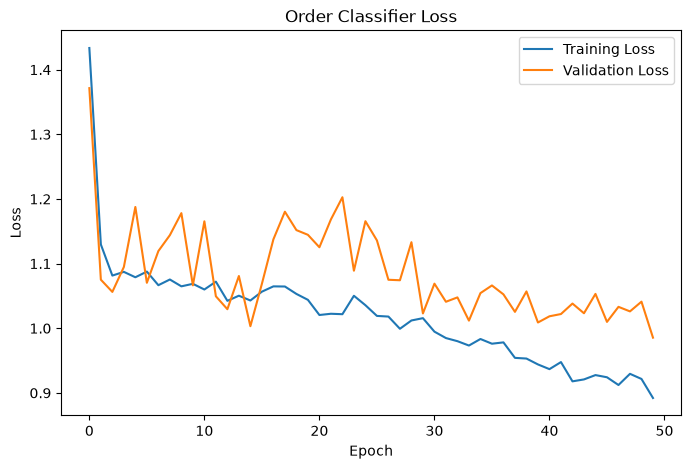

In [37]:
plt.figure(figsize = (8, 5))

plt.plot(order_lr_hist.history["loss"], label = "Training Loss")
plt.plot(order_lr_hist.history["val_loss"], label = "Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Order Classifier Loss")
plt.legend()
plt.show()

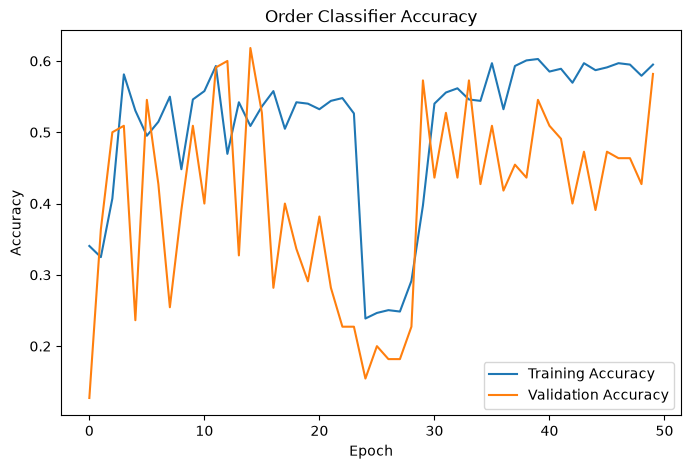

In [38]:
plt.figure(figsize = (8, 5))

plt.plot(
    order_lr_hist.history["sparse_categorical_accuracy"],
    label = "Training Accuracy"
)

plt.plot(
    order_lr_hist.history["val_sparse_categorical_accuracy"],
    label = "Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Order Classifier Accuracy")
plt.legend()
plt.show()

In [39]:
val_prob = order_model_lr.predict(x_val)
val_pred = np.argmax(val_prob, axis = 1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


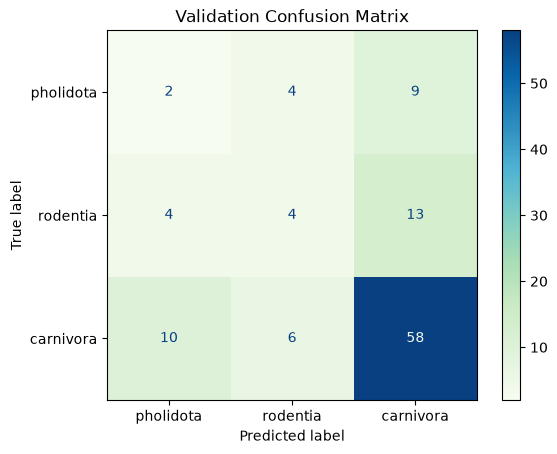

In [40]:
cm = confusion_matrix(y_val, val_pred)

disp = ConfusionMatrixDisplay(
            confusion_matrix = cm,
            display_labels = ["pholidota", "rodentia", "carnivora"]
        )

disp.plot(cmap = "GnBu")
plt.title("Validation Confusion Matrix")
plt.show()

In [41]:
print(
    classification_report(
        y_val,
        val_pred,
        target_names = ["pholidota", "rodentia", "carnivora"],
        zero_division = 0
    )
)

              precision    recall  f1-score   support

   pholidota       0.12      0.13      0.13        15
    rodentia       0.29      0.19      0.23        21
   carnivora       0.72      0.78      0.75        74

    accuracy                           0.58       110
   macro avg       0.38      0.37      0.37       110
weighted avg       0.56      0.58      0.57       110



In [42]:
macro_f1 = f1_score(
                y_val,
                val_pred,
                average = "macro"
            )

print("Macro F1:", macro_f1)

Macro F1: 0.37028347996089933


In [43]:
print(val_prob[:5])
print(np.unique(val_pred, return_counts = True))

[[0.24341029 0.3217095  0.43488023]
 [0.4165039  0.268282   0.31521407]
 [0.19614348 0.3435358  0.46032074]
 [0.19112603 0.36429235 0.44458163]
 [0.33746892 0.3043965  0.35813454]]
(array([0, 1, 2]), array([16, 14, 80]))


For context, Carnivora is the majority order in the validation/test split. A classifier that always predicted Carnivora would achieve a relatively high accuracy simply because of the class imbalance. This is why macro F1 was treated as the main model-selection metric rather than accuracy alone: macro F1 gives equal importance to minority classes such as Pholidota & Rodentia.

In [44]:
hidden_check = keras.Model(
                    inputs = order_model_lr.inputs,
                    outputs = order_model_lr.layers[0].output
                )

hidden_values = hidden_check.predict(x_val[:5])

print(np.sum(hidden_values == 0, axis = 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
[62 62 62 62 61]


The failure of the ReLU configurations suggests that the optimisation setup was interacting poorly with the high-dimensional flattened input. The near-uniform class probabilities indicated that the network was not learning sufficiently discriminative internal representations.

In [45]:
order_model_tanh = tf.keras.Sequential([
    keras.Input(shape = (19200,)),
    layers.Dense(64, activation = "tanh"),
    layers.Dropout(0.1),
    layers.Dense(3, activation = "softmax")
])

order_model_tanh.compile(
    optimizer = keras.optimizers.AdamW(learning_rate = 1e-4),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
)

order_tanh_hist = order_model_tanh.fit(
                        x_train,
                        y_train,
                        batch_size = 16,
                        epochs = 50,
                        validation_data = (x_val, y_val),
                        class_weight = db_results,
                        verbose = 0
                    )

In [46]:
tanh_prob = order_model_tanh.predict(x_val)
tanh_pred = np.argmax(tanh_prob, axis = 1)

print(
    classification_report(
        y_val,
        tanh_pred,
        target_names = ["pholidota", "rodentia", "carnivora"],
        zero_division = 0
    )
)

print("Macro F1:", f1_score(y_val, tanh_pred, average = "macro"))
print(np.unique(tanh_pred, return_counts = True))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
              precision    recall  f1-score   support

   pholidota       0.17      0.20      0.18        15
    rodentia       0.23      0.52      0.32        21
   carnivora       0.77      0.46      0.58        74

    accuracy                           0.44       110
   macro avg       0.39      0.39      0.36       110
weighted avg       0.59      0.44      0.47       110

Macro F1: 0.35897664932300155
(array([0, 1, 2]), array([18, 48, 44]))


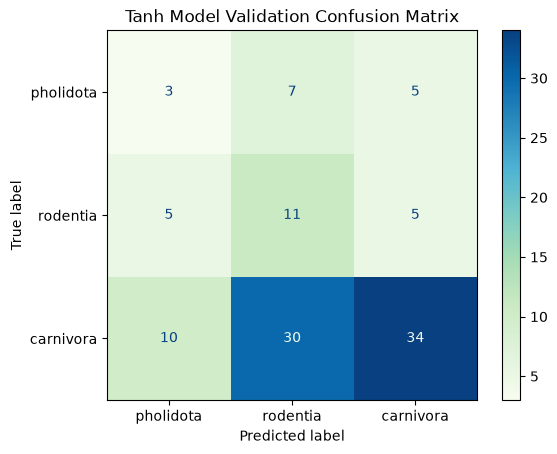

In [47]:
cm = confusion_matrix(y_val, tanh_pred)

disp = ConfusionMatrixDisplay(
            confusion_matrix = cm,
            display_labels = ["pholidota", "rodentia", "carnivora"]
        )

disp.plot(cmap = "GnBu")
plt.title("Tanh Model Validation Confusion Matrix")
plt.show()

### Tanh Model Results

Replacing ReLU with tanh produced predictions across all three orders & avoided the severe hidden-unit inactivity observed in the earlier ReLU experiments.

The tanh model achieved a validation accuracy of approximately 44% & a macro F1 score of approximately 0.36. Carnivora achieved the highest F1 score at approximately 0.58, followed by Rodentia at approximately 0.32 & Pholidota at approximately 0.18.

The reduced-learning-rate ReLU model achieved a slightly higher validation macro F1 of approximately 0.37. However, the tanh model produced stronger recall for the minority classes, particularly Rodentia, & distributed its predictions across all three orders rather than strongly favouring the majority class.

This illustrates an important trade-off between aggregate performance & minority-class recognition. Since the dataset is imbalanced & the conservation context makes minority-class recall important, the tanh configuration was retained for the hierarchical experiments.

Overall performance nevertheless remained limited. This suggests that the main challenge was not only activation choice, but also the difficulty of learning useful visual structure from flattened raw pixels using Dense layers alone.

## 8. Hierarchical Classification

After classification at the order level, additional classifiers were trained for branches containing multiple possible child taxa. Branches containing only one possible child were treated as deterministic & therefore did not require an additional neural network.

Hierarchical subsets & local label arrays were constructed using NumPy boolean indexing & array operations (NumPy Developers, 2026).

### Rodentia Family Classifier

The Rodentia branch contains two families in the selected dataset: Sciuridae & Hystricidae. A binary family classifier was therefore trained using only images belonging to the Rodentia order.

In [48]:
rod_mask = y_order_arr == 1

x_rod = x_order_arr[rod_mask]
rod_family_global = y_family_arr[rod_mask]

In [49]:
y_rod = np.where(
            rod_family_global == family_to_int["sciuridae"],
            0,
            1
        ).astype("int32")

print("Rodentia X:", x_rod.shape)
print("Rodentia y:", y_rod.shape)
print(
    "Class counts:",
    np.unique(y_rod, return_counts = True)
)

Rodentia X: (140, 19200)
Rodentia y: (140,)
Class counts: (array([0, 1], dtype=int32), array([ 40, 100]))


In [50]:
x_rod_train, x_rod_temp, y_rod_train, y_rod_temp = train_test_split(
    x_rod,
    y_rod,
    test_size = 0.3,
    stratify = y_rod,
    random_state = 42
)

x_rod_val, x_rod_test, y_rod_val, y_rod_test = train_test_split(
    x_rod_temp,
    y_rod_temp,
    test_size = 0.5,
    stratify = y_rod_temp,
    random_state = 42
)

print(x_rod_train.shape, y_rod_train.shape)
print(x_rod_val.shape, y_rod_val.shape)
print(x_rod_test.shape, y_rod_test.shape)

(98, 19200) (98,)
(21, 19200) (21,)
(21, 19200) (21,)


In [51]:
rod_classes = np.unique(y_rod_train)

rod_weights = compute_class_weight(
    class_weight = "balanced",
    classes = rod_classes,
    y = y_rod_train
)

rod_class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(rod_classes, rod_weights)
}

print(rod_class_weights)

{0: 1.75, 1: 0.7}


In [52]:
rod_model = tf.keras.Sequential([
                keras.Input(shape=(19200,)),
                layers.Dense(64, activation = "tanh"),
                layers.Dropout(0.1),
                layers.Dense(2, activation = "softmax")
            ])

rod_model.compile(
    optimizer = keras.optimizers.AdamW(learning_rate=1e-4),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
)

rod_hist = rod_model.fit(
                x_rod_train,
                y_rod_train,
                batch_size = 16,
                epochs = 50,
                validation_data = (x_rod_val, y_rod_val),
                class_weight = rod_class_weights,
                verbose = 0
            )

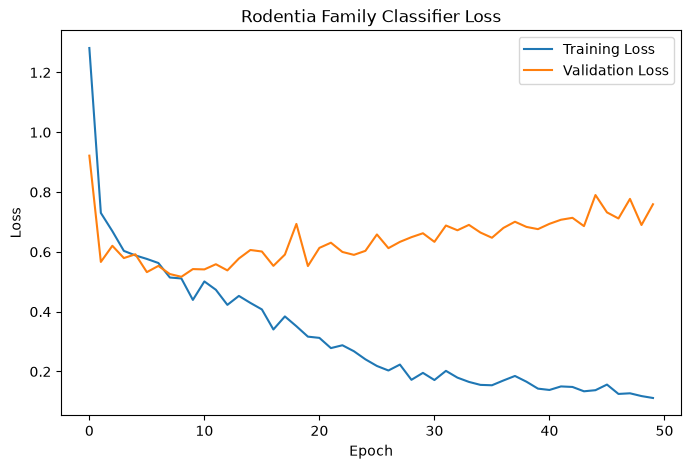

In [53]:
plt.figure(figsize = (8, 5))

plt.plot(rod_hist.history["loss"], label = "Training Loss")
plt.plot(rod_hist.history["val_loss"], label = "Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Rodentia Family Classifier Loss")
plt.legend()
plt.show()

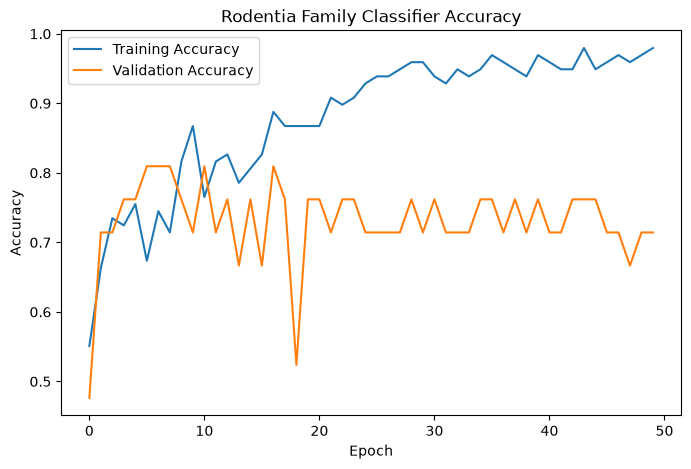

In [54]:
plt.figure(figsize = (8, 5))

plt.plot(
    rod_hist.history["sparse_categorical_accuracy"],
    label = "Training Accuracy"
)

plt.plot(
    rod_hist.history["val_sparse_categorical_accuracy"],
    label = "Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Rodentia Family Classifier Accuracy")
plt.legend()
plt.show()

In [55]:
rod_prob = rod_model.predict(x_rod_val)
rod_pred = np.argmax(rod_prob, axis = 1)

print(
    classification_report(
        y_rod_val,
        rod_pred,
        target_names = ["sciuridae", "hystricidae"],
        zero_division = 0
    )
)

print(
    "Macro F1:",
    f1_score(y_rod_val, rod_pred, average = "macro")
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
              precision    recall  f1-score   support

   sciuridae       0.50      0.33      0.40         6
 hystricidae       0.76      0.87      0.81        15

    accuracy                           0.71        21
   macro avg       0.63      0.60      0.61        21
weighted avg       0.69      0.71      0.69        21

Macro F1: 0.60625


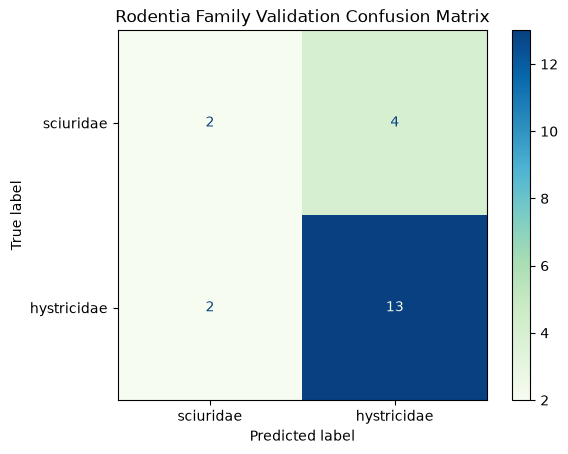

In [56]:
rod_cm = confusion_matrix(y_rod_val, rod_pred)

rod_disp = ConfusionMatrixDisplay(
                confusion_matrix = rod_cm,
                display_labels = ["sciuridae", "hystricidae"]
            )

rod_disp.plot(cmap = "GnBu")
plt.title("Rodentia Family Validation Confusion Matrix")
plt.show()

### Rodentia Family Classifier Results

The Rodentia family classifier achieved a validation accuracy of approximately 71% & a macro F1 score of approximately 0.61.

The model performed better on Hystricidae than on Sciuridae. Hystricidae achieved an F1 score of approximately 0.81, while Sciuridae achieved an F1 score of approximately 0.40. The confusion matrix showed that 13 of 15 Hystricidae validation samples were classified correctly, compared with 2 of 6 Sciuridae samples.

The learning curves indicate overfitting. Training loss continued to decrease while validation loss remained relatively stable & fluctuated at a higher level. Similarly, training accuracy increased substantially while validation accuracy remained lower. This suggests that the model learned the training data more strongly than it generalised to unseen validation images.

Despite these limitations, the classifier demonstrated meaningful discrimination between the two Rodentia families & was retained as the Rodentia branch of the hierarchical classification system.

### Carnivora Family Classifier

The Carnivora branch contains three families in the selected dataset: Felidae, Viverridae & Mustelidae. A three-class family classifier was therefore trained using only images belonging to the Carnivora order.

In [57]:
# create Carnivora subset
carn_mask = y_order_arr == 2

x_carn = x_order_arr[carn_mask]
carn_family_global = y_family_arr[carn_mask]

# local family labels:
# 0 = Felidae
# 1 = Viverridae
# 2 = Mustelidae

y_carn = np.zeros(len(carn_family_global), dtype = "int32")

y_carn[carn_family_global == family_to_int["felidae"]] = 0
y_carn[carn_family_global == family_to_int["viverridae"]] = 1
y_carn[carn_family_global == family_to_int["mustelidae"]] = 2

print("Carnivora X:", x_carn.shape)
print("Carnivora y:", y_carn.shape)
print("Class counts:", np.unique(y_carn, return_counts = True))

Carnivora X: (492, 19200)
Carnivora y: (492,)
Class counts: (array([0, 1, 2], dtype=int32), array([100, 202, 190]))


In [58]:
x_carn_train, x_carn_temp, y_carn_train, y_carn_temp = train_test_split(
                                                            x_carn,
                                                            y_carn,
                                                            test_size = 0.3,
                                                            stratify = y_carn,
                                                            random_state = 42
                                                        )

x_carn_val, x_carn_test, y_carn_val, y_carn_test = train_test_split(
                                                        x_carn_temp,
                                                        y_carn_temp,
                                                        test_size = 0.5,
                                                        stratify = y_carn_temp,
                                                        random_state = 42
                                                    )

print(x_carn_train.shape, y_carn_train.shape)
print(x_carn_val.shape, y_carn_val.shape)
print(x_carn_test.shape, y_carn_test.shape)

(344, 19200) (344,)
(74, 19200) (74,)
(74, 19200) (74,)


In [59]:
carn_classes = np.unique(y_carn_train)

carn_weights = compute_class_weight(
                    class_weight = "balanced",
                    classes = carn_classes,
                    y = y_carn_train
                )

carn_class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(carn_classes, carn_weights)
}

print(carn_class_weights)

{0: 1.638095238095238, 1: 0.8132387706855791, 2: 0.8621553884711779}


In [60]:
carn_model = tf.keras.Sequential([
                    keras.Input(shape = (19200,)),
                    layers.Dense(64, activation = "tanh"),
                    layers.Dropout(0.1),
                    layers.Dense(3, activation = "softmax")
                ])

carn_model.compile(
    optimizer = keras.optimizers.AdamW(learning_rate = 1e-4),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
)

carn_hist = carn_model.fit(
                x_carn_train,
                y_carn_train,
                batch_size = 16,
                epochs = 50,
                validation_data = (x_carn_val, y_carn_val),
                class_weight = carn_class_weights,
                verbose = 0
            )

In [61]:
carn_prob = carn_model.predict(x_carn_val)
carn_pred = np.argmax(carn_prob, axis = 1)

print(
    classification_report(
        y_carn_val,
        carn_pred,
        target_names = ["felidae", "viverridae", "mustelidae"],
        zero_division = 0
    )
)

print(
    "Macro F1:",
    f1_score(y_carn_val, carn_pred, average = "macro")
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
              precision    recall  f1-score   support

     felidae       0.44      0.27      0.33        15
  viverridae       0.59      0.53      0.56        30
  mustelidae       0.53      0.69      0.60        29

    accuracy                           0.54        74
   macro avg       0.52      0.50      0.50        74
weighted avg       0.54      0.54      0.53        74

Macro F1: 0.4972505891594658


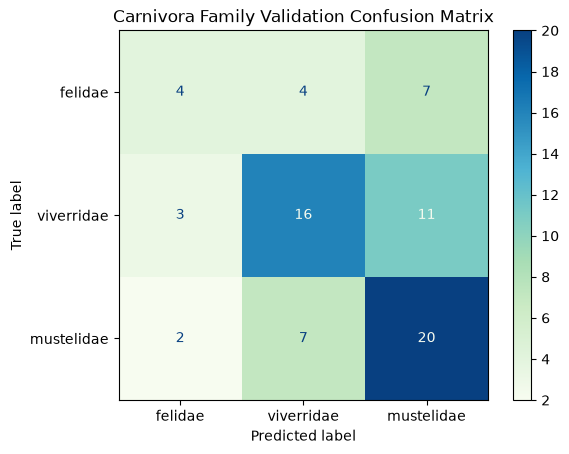

In [62]:
carn_cm = confusion_matrix(y_carn_val, carn_pred)

carn_disp = ConfusionMatrixDisplay(
                confusion_matrix = carn_cm,
                display_labels = ["felidae", "viverridae", "mustelidae"]
            )

carn_disp.plot(cmap = "GnBu")
plt.title("Carnivora Family Validation Confusion Matrix")
plt.show()

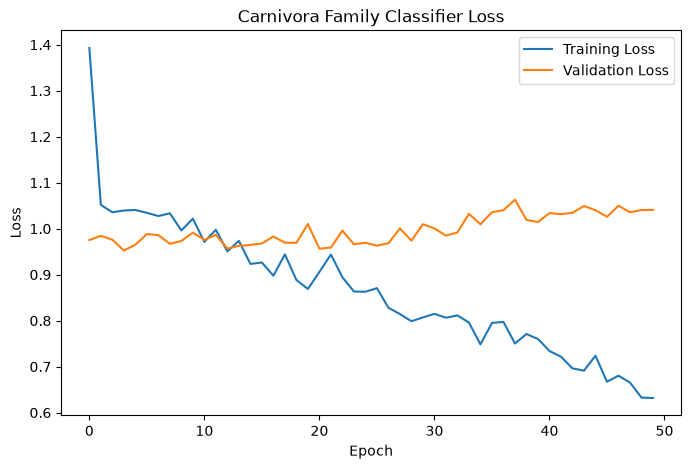

In [63]:
plt.figure(figsize = (8, 5))
plt.plot(carn_hist.history["loss"], label = "Training Loss")
plt.plot(carn_hist.history["val_loss"], label = "Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Carnivora Family Classifier Loss")
plt.legend()
plt.show()

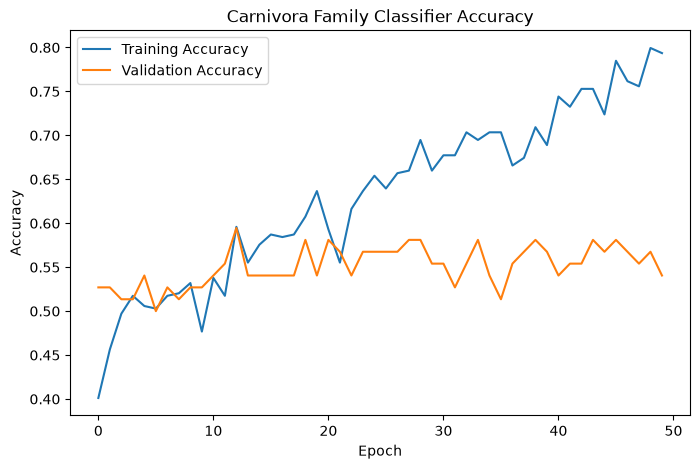

In [64]:
plt.figure(figsize = (8, 5))
plt.plot(
    carn_hist.history["sparse_categorical_accuracy"],
    label = "Training Accuracy"
)
plt.plot(
    carn_hist.history["val_sparse_categorical_accuracy"],
    label = "Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Carnivora Family Classifier Accuracy")
plt.legend()
plt.show()

### Carnivora Family Classifier Results

The Carnivora family classifier achieved a validation accuracy of approximately 54% & a macro F1 score of approximately 0.50.

The classifier performed best on Mustelidae, which achieved an F1 score of approximately 0.60, followed by Viverridae at approximately 0.56. Felidae was the most difficult family to classify, with an F1 score of approximately 0.33.

The confusion matrix shows that 20 of 29 Mustelidae validation samples & 16 of 30 Viverridae samples were classified correctly, while 4 of 15 Felidae samples were correctly identified.

The learning curves show some separation between training & validation performance, suggesting mild overfitting. However, the classifier continued to distinguish all three Carnivora families & was retained as the Carnivora branch of the hierarchical classification system.

### Viverridae Species Classifier

The Viverridae branch contains three species: Small-tooth Palm Civet, Masked Palm Civet & Large Indian Civet. A three-class species classifier was trained using only images belonging to the Viverridae family.

In [65]:
viv_mask = y_family_arr == family_to_int["viverridae"]

x_viv = x_order_arr[viv_mask]
viv_species_global = y_species_arr[viv_mask]

viv_species_names = [
    "small-tooth palm civet",
    "masked palm civet",
    "large indian civet"
]

viv_species_ids = [
    species_to_int["small-tooth palm civet"],
    species_to_int["masked palm civet"],
    species_to_int["large indian civet"]
]

y_viv = np.zeros(len(viv_species_global), dtype = "int32")

for local_id, global_id in enumerate(viv_species_ids):
    y_viv[viv_species_global == global_id] = local_id

print("Viverridae X:", x_viv.shape)
print("Viverridae y:", y_viv.shape)
print("Class counts:", np.unique(y_viv, return_counts = True))

Viverridae X: (202, 19200)
Viverridae y: (202,)
Class counts: (array([0, 1, 2], dtype=int32), array([82, 80, 40]))


In [66]:
x_viv_train, x_viv_temp, y_viv_train, y_viv_temp = train_test_split(
                                                        x_viv,
                                                        y_viv,
                                                        test_size = 0.3,
                                                        stratify = y_viv,
                                                        random_state = 42
                                                    )

x_viv_val, x_viv_test, y_viv_val, y_viv_test = train_test_split(
                                                    x_viv_temp,
                                                    y_viv_temp,
                                                    test_size = 0.5,
                                                    stratify = y_viv_temp,
                                                    random_state = 42
                                                )

In [67]:
viv_classes = np.unique(y_viv_train)

viv_weights = compute_class_weight(
                    class_weight = "balanced",
                    classes = viv_classes,
                    y = y_viv_train
                )

viv_class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(viv_classes, viv_weights)
}

In [68]:
viv_model = tf.keras.Sequential([
    keras.Input(shape = (19200,)),
    layers.Dense(64, activation = "tanh"),
    layers.Dropout(0.1),
    layers.Dense(3, activation = "softmax")
])

viv_model.compile(
    optimizer = keras.optimizers.AdamW(learning_rate = 1e-4),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
)

viv_hist = viv_model.fit(
    x_viv_train,
    y_viv_train,
    batch_size = 16,
    epochs = 50,
    validation_data = (x_viv_val, y_viv_val),
    class_weight = viv_class_weights,
    verbose = 0
)

In [69]:
viv_prob = viv_model.predict(x_viv_val)
viv_pred = np.argmax(viv_prob, axis = 1)

print(
    classification_report(
        y_viv_val,
        viv_pred,
        target_names = [
            "small-tooth palm civet",
            "masked palm civet",
            "large indian civet"
        ],
        zero_division = 0
    )
)

print(
    "Macro F1:",
    f1_score(y_viv_val, viv_pred, average = "macro")
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
                        precision    recall  f1-score   support

small-tooth palm civet       0.80      0.33      0.47        12
     masked palm civet       0.64      0.58      0.61        12
    large indian civet       0.29      0.67      0.40         6

              accuracy                           0.50        30
             macro avg       0.57      0.53      0.49        30
          weighted avg       0.63      0.50      0.51        30

Macro F1: 0.49309462915601027


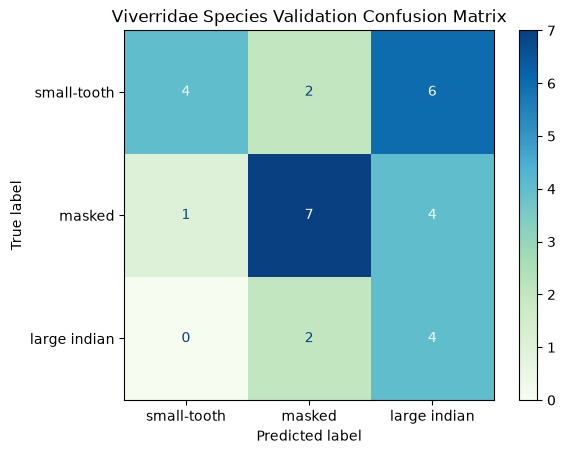

In [70]:
viv_cm = confusion_matrix(y_viv_val, viv_pred)

viv_disp = ConfusionMatrixDisplay(
    confusion_matrix = viv_cm,
    display_labels = [
        "small-tooth",
        "masked",
        "large indian"
    ]
)

viv_disp.plot(cmap = "GnBu")
plt.title("Viverridae Species Validation Confusion Matrix")
plt.show()

### Mustelidae Species Classifier

The Mustelidae branch contains two species: Asian Small-clawed Otter & Smooth-coated Otter. A binary species classifier was trained using only images belonging to the Mustelidae family.

In [71]:
must_mask = y_family_arr == family_to_int["mustelidae"]

x_must = x_order_arr[must_mask]
must_species_global = y_species_arr[must_mask]

must_species_ids = [
    species_to_int["asian small-clawed otter"],
    species_to_int["smooth-coated otter"]
]

y_must = np.zeros(len(must_species_global), dtype = "int32")

y_must[must_species_global == must_species_ids[0]] = 0
y_must[must_species_global == must_species_ids[1]] = 1

print("Mustelidae X:", x_must.shape)
print("Mustelidae y:", y_must.shape)
print("Class counts:", np.unique(y_must, return_counts = True))

Mustelidae X: (190, 19200)
Mustelidae y: (190,)
Class counts: (array([0, 1], dtype=int32), array([ 90, 100]))


In [72]:
x_must_train, x_must_temp, y_must_train, y_must_temp = train_test_split(
                                                            x_must,
                                                            y_must,
                                                            test_size = 0.3,
                                                            stratify = y_must,
                                                            random_state = 42
                                                        )

x_must_val, x_must_test, y_must_val, y_must_test = train_test_split(
                                                        x_must_temp,
                                                        y_must_temp,
                                                        test_size = 0.5,
                                                        stratify = y_must_temp,
                                                        random_state = 42
                                                    )

must_classes = np.unique(y_must_train)

must_weights = compute_class_weight(
                    class_weight = "balanced",
                    classes = must_classes,
                    y = y_must_train
                )

must_class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(must_classes, must_weights)
}

In [73]:
must_model = tf.keras.Sequential([
    keras.Input(shape = (19200,)),
    layers.Dense(64, activation = "tanh"),
    layers.Dropout(0.1),
    layers.Dense(2, activation = "softmax")
])

must_model.compile(
    optimizer = keras.optimizers.AdamW(learning_rate = 1e-4),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
)

must_hist = must_model.fit(
                x_must_train,
                y_must_train,
                batch_size = 16,
                epochs = 50,
                validation_data = (x_must_val, y_must_val),
                class_weight = must_class_weights,
                verbose = 0
            )

In [74]:
must_prob = must_model.predict(x_must_val)
must_pred = np.argmax(must_prob, axis = 1)

print(
    classification_report(
        y_must_val,
        must_pred,
        target_names = [
            "asian small-clawed otter",
            "smooth-coated otter"
        ],
        zero_division = 0
    )
)

print(
    "Macro F1:",
    f1_score(y_must_val, must_pred, average = "macro")
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
                          precision    recall  f1-score   support

asian small-clawed otter       0.78      0.54      0.64        13
     smooth-coated otter       0.68      0.87      0.76        15

                accuracy                           0.71        28
               macro avg       0.73      0.70      0.70        28
            weighted avg       0.73      0.71      0.71        28

Macro F1: 0.7005347593582887


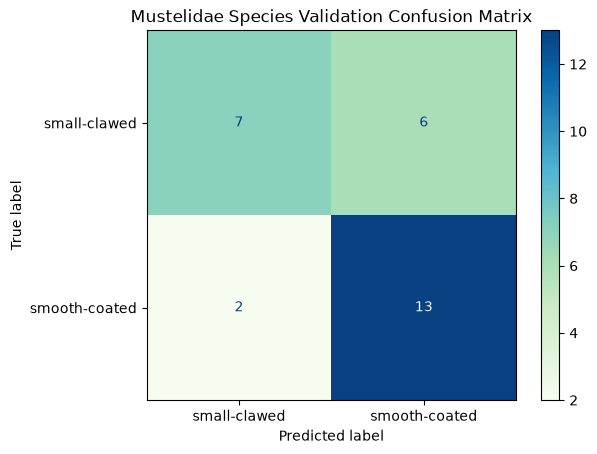

In [75]:
must_cm = confusion_matrix(y_must_val, must_pred)

must_disp = ConfusionMatrixDisplay(
    confusion_matrix = must_cm,
    display_labels = [
        "small-clawed",
        "smooth-coated"
    ]
)

must_disp.plot(cmap = "GnBu")
plt.title("Mustelidae Species Validation Confusion Matrix")
plt.show()

## 9. Final Test Evaluation

After model development & selection using the validation sets, the retained classifiers were evaluated on their previously unseen test sets. These test results provide the final estimate of generalisation performance & were not used for model selection.

The lower-level Rodentia, Carnivora, Viverridae & Mustelidae classifiers were evaluated only on samples already known to belong to the correct parent taxon. Their test scores are therefore conditional branch-level results & should not be interpreted as the end-to-end species-classification accuracy of the full hierarchy.

In [76]:
# Order model
order_test_prob = order_model_tanh.predict(x_test)
order_test_pred = np.argmax(order_test_prob, axis = 1)

print("ORDER CLASSIFIER")
print(
    classification_report(
        y_test,
        order_test_pred,
        target_names = ["pholidota", "rodentia", "carnivora"],
        zero_division = 0
    )
)
print("Macro F1:", f1_score(y_test, order_test_pred, average = "macro"))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
ORDER CLASSIFIER
              precision    recall  f1-score   support

   pholidota       0.17      0.27      0.21        15
    rodentia       0.32      0.57      0.41        21
   carnivora       0.79      0.51      0.62        74

    accuracy                           0.49       110
   macro avg       0.42      0.45      0.41       110
weighted avg       0.62      0.49      0.52       110

Macro F1: 0.41161956193909516


In [77]:
# Rodentia family model
rod_test_prob = rod_model.predict(x_rod_test)
rod_test_pred = np.argmax(rod_test_prob, axis = 1)

print("RODENTIA FAMILY CLASSIFIER")
print(
    classification_report(
        y_rod_test,
        rod_test_pred,
        target_names = ["sciuridae", "hystricidae"],
        zero_division = 0
    )
)
print("Macro F1:", f1_score(y_rod_test, rod_test_pred, average = "macro"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
RODENTIA FAMILY CLASSIFIER
              precision    recall  f1-score   support

   sciuridae       0.50      0.33      0.40         6
 hystricidae       0.76      0.87      0.81        15

    accuracy                           0.71        21
   macro avg       0.63      0.60      0.61        21
weighted avg       0.69      0.71      0.69        21

Macro F1: 0.60625


The Rodentia family classifier showed meaningful separation between Sciuridae & Hystricidae, achieving both a validation & final test macro F1 of approximately 0.61.

The final test accuracy was approximately 71%. Performance remained considerably stronger for Hystricidae than for Sciuridae, indicating that the smaller Sciuridae class remained more difficult to recognise.

These results should still be interpreted cautiously because the branch contains relatively few samples, meaning that a small number of changed predictions can noticeably affect the reported metrics.

In [78]:
# Carnivora family model
carn_test_prob = carn_model.predict(x_carn_test)
carn_test_pred = np.argmax(carn_test_prob, axis = 1)

print("CARNIVORA FAMILY CLASSIFIER")
print(
    classification_report(
        y_carn_test,
        carn_test_pred,
        target_names = ["felidae", "viverridae", "mustelidae"],
        zero_division = 0
    )
)
print("Macro F1:", f1_score(y_carn_test, carn_test_pred, average = "macro"))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
CARNIVORA FAMILY CLASSIFIER
              precision    recall  f1-score   support

     felidae       0.36      0.27      0.31        15
  viverridae       0.57      0.55      0.56        31
  mustelidae       0.58      0.68      0.62        28

    accuracy                           0.54        74
   macro avg       0.50      0.50      0.50        74
weighted avg       0.53      0.54      0.53        74

Macro F1: 0.49600672551492225


The Carnivora family classifier achieved a final test accuracy of approximately 54% and a macro F1 score of approximately 0.50.

Felidae remained the weakest class. Four of the 15 Felidae test images were correctly identified, corresponding to a recall of approximately 0.27 & an F1 score of approximately 0.31.

This is particularly important in the hierarchical system because Mainland Leopard Cat is the only selected species under Felidae. A Felidae image that is incorrectly routed at the family stage cannot subsequently receive the correct species label.

In [79]:
# Viverridae species model
viv_test_prob = viv_model.predict(x_viv_test)
viv_test_pred = np.argmax(viv_test_prob, axis = 1)

print("VIVERRIDAE SPECIES CLASSIFIER")
print(
    classification_report(
        y_viv_test,
        viv_test_pred,
        target_names = [
            "small-tooth palm civet",
            "masked palm civet",
            "large indian civet"
        ],
        zero_division = 0
    )
)
print("Macro F1:", f1_score(y_viv_test, viv_test_pred, average = "macro"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
VIVERRIDAE SPECIES CLASSIFIER
                        precision    recall  f1-score   support

small-tooth palm civet       0.78      0.54      0.64        13
     masked palm civet       0.67      0.67      0.67        12
    large indian civet       0.40      0.67      0.50         6

              accuracy                           0.61        31
             macro avg       0.61      0.62      0.60        31
          weighted avg       0.66      0.61      0.62        31

Macro F1: 0.601010101010101


The Viverridae species classifier achieved a final test accuracy of approximately 61% & a macro F1 score of approximately 0.60, compared with a validation macro F1 of approximately 0.49.

Masked Palm Civet achieved the strongest test F1 score at approximately 0.67, followed by Small-tooth Palm Civet at approximately 0.64 & Large Indian Civet at approximately 0.50.

The higher test result should not be interpreted as evidence that the model improved after validation. The validation & test subsets are relatively small, so a small number of changed predictions can noticeably affect the reported metrics.

In [80]:
# Mustelidae species model
must_test_prob = must_model.predict(x_must_test)
must_test_pred = np.argmax(must_test_prob, axis = 1)

print("MUSTELIDAE SPECIES CLASSIFIER")
print(
    classification_report(
        y_must_test,
        must_test_pred,
        target_names = [
            "asian small-clawed otter",
            "smooth-coated otter"
        ],
        zero_division = 0
    )
)
print("Macro F1:", f1_score(y_must_test, must_test_pred, average = "macro"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
MUSTELIDAE SPECIES CLASSIFIER
                          precision    recall  f1-score   support

asian small-clawed otter       0.83      0.36      0.50        14
     smooth-coated otter       0.61      0.93      0.74        15

                accuracy                           0.66        29
               macro avg       0.72      0.65      0.62        29
            weighted avg       0.72      0.66      0.62        29

Macro F1: 0.618421052631579


The Mustelidae species classifier achieved a final test accuracy of approximately 66% & a macro F1 score of approximately 0.62.

Performance differed substantially between the two otter species. Asian Small-clawed Otter achieved a recall of approximately 0.36 & an F1 score of approximately 0.50, while Smooth-coated Otter achieved a recall of approximately 0.93 & an F1 score of approximately 0.74.

The small test set means that these estimates should still be treated cautiously rather than as highly stable measurements of generalisation performance.

After model selection using validation performance, the retained configurations were evaluated once on the held-out test sets. No further hyperparameter changes were made using test-set results.

## Final Test Results

The selected classifiers were evaluated on their previously unseen test sets after model development had been completed using the validation sets.

## Final Model Comparison

| Classifier | Validation Macro F1 | Test Macro F1 | Test Accuracy |
|---|---:|---:|---:|
| Order | 0.359 | 0.412 | 0.49 |
| Rodentia Family | 0.606 | 0.606 | 0.71 |
| Carnivora Family | 0.497 | 0.496 | 0.54 |
| Viverridae Species | 0.493 | 0.601 | 0.61 |
| Mustelidae Species | 0.701 | 0.618 | 0.66 |

The lower-level classifiers were evaluated independently within their respective taxonomic subsets. Therefore, the reported branch metrics measure component-level performance rather than the accuracy of a single end-to-end species-classification pipeline. In a deployed hierarchy, an incorrect upstream prediction would prevent the image from reaching the correct downstream branch.

The strongest test macro F1 was produced by the Mustelidae species classifier at approximately 0.62, followed closely by the Rodentia family classifier at approximately 0.61 & the Viverridae species classifier at approximately 0.60. Rodentia achieved the highest test accuracy at approximately 71%.

The Order classifier achieved approximately 49% test accuracy & a macro F1 score of approximately 0.41. Performance was strongest for Carnivora, while Pholidota and Rodentia remained more difficult to classify reliably.

The Carnivora family classifier achieved approximately 54% test accuracy & a macro F1 score of approximately 0.50. Mustelidae & Viverridae were identified with moderate success, while Felidae remained the weakest family.

The Viverridae species classifier achieved approximately 61% test accuracy & a macro F1 score of approximately 0.60. Masked Palm Civet produced the highest test F1 score at approximately 0.67, followed by Small-tooth Palm Civet at approximately 0.64 & Large Indian Civet at approximately 0.50.

The Mustelidae species classifier achieved approximately 66% accuracy & a macro F1 score of approximately 0.62. Smooth-coated Otter was recognised considerably more reliably than Asian Small-clawed Otter.

Validation & test performance differed across several branches. For example, the Mustelidae classifier declined from approximately 0.70 validation macro F1 to approximately 0.62 on the test set, while the Viverridae classifier increased from approximately 0.49 to approximately 0.60.

These differences should not be interpreted as evidence that one subset is intrinsically easier or harder. The lower-level datasets are relatively small, so their validation and test subsets contain only a limited number of images. Consequently, a small number of changed predictions can produce substantial changes in accuracy or macro F1. This increases uncertainty around the reported point estimates & is an important limitation of the study.

Overall, performance varied substantially across the hierarchy. Branches with fewer classes generally produced stronger macro F1 scores than the broader Order classifier, although class imbalance & small sample sizes continued to affect performance.

## 10. Discussion & Limitations

The results show that hierarchical classification was feasible using a Dense-only neural network approach, but performance was limited by several factors.

A major limitation was the use of flattened image pixels. Each 80 × 80 RGB image was converted into a 19,200-dimensional vector before being passed to Dense layers. This satisfies the project restriction of using only Dense & Dropout TensorFlow layers, but it removes the explicit spatial structure of the image. As a result, the model cannot directly exploit local visual patterns in the way that convolutional models normally would. The use of white padding may also introduce artificial high-intensity borders around some images. These borders are unrelated to species identity & could potentially influence the Dense network's learned features.

The Dense architecture also contains a large number of trainable parameters relative to the available dataset. With 19,200 input features & 64 hidden units, the first Dense layer alone contains more than one million parameters. This high parameter-to-sample ratio increases the risk of overfitting, particularly because the order-level training set contains only a few hundred images.

Class imbalance was another important challenge. Carnivora contained substantially more samples than Pholidota & Rodentia, while several lower-level species classes also had unequal representation. Class weighting was used to reduce this imbalance during training, but minority classes remained more difficult to classify.

Some models showed signs of overfitting, particularly within the lower-level hierarchical branches. This was visible in the Rodentia family classifier, where training performance continued to improve while validation performance remained lower. The Order classifier also experienced unstable optimisation during earlier ReLU experiments, including configurations that collapsed towards single-class predictions & severe hidden-unit inactivity. Reducing the learning rate improved the ReLU model, while replacing ReLU with tanh produced more balanced minority-class predictions & avoided the severe inactivity observed in the earlier ReLU configuration.

The hierarchical design introduces an additional source of error propagation. If an image is classified incorrectly at the order level, it will be passed to the wrong lower-level classifier. Therefore, errors made near the top of the hierarchy can prevent correct species identification even when a lower-level classifier performs well.

The dataset itself also introduces limitations. Images were collected from iNaturalist & therefore vary in lighting, viewpoint, scale, background, image quality & photographic conditions. In addition, species relevant to Singapore were represented using images from the broader Southeast Asian region because sufficient local images were not available for all classes.

Despite these limitations, the project demonstrates a complete machine-learning workflow including data acquisition, preprocessing, class-imbalance handling, model experimentation, validation-based model selection, hierarchical classification & final test evaluation.

For practical use, the classifier would be more appropriate as an assistive
screening tool than as an autonomous decision system. Predictions could be used
to prioritise or pre-label wildlife images for expert review, while uncertain
or conservation-critical cases would still require human verification.

### Conservation Interpretation

In a conservation-monitoring setting, errors are not equally important. A false negative for a rare or threatened taxon may result in an observation being overlooked, while a false positive may direct limited expert-review effort toward an incorrect record.

The low recall observed for some minority taxa therefore matters beyond the aggregate accuracy score. In particular, weak recognition of Pholidota at the order level means that Sunda Pangolin observations could be routed incorrectly before species identification is reached. Similarly, the Carnivora family classifier correctly identified only 4 of 15 Felidae test examples, corresponding to a recall of approximately 0.27. This means Mainland Leopard Cat images would remain particularly vulnerable to hierarchical routing errors.

For this reason, macro F1 & class-level recall provide more useful information than overall accuracy alone when judging the conservation relevance of the system.


### Implications for Wildlife Monitoring

The classifier developed here should be viewed as an assistive component within a broader biodiversity-monitoring workflow rather than as a replacement for ecological field methods. Population abundance & population trends cannot be inferred from species classification alone because they also depend on sampling effort, repeated observations, detectability & survey design.

The potential contribution of image classification is instead at the image-processing stage. If a sufficiently reliable classifier can automatically propose taxonomic labels for large collections of wildlife photographs, researchers could prioritise uncertain cases for manual review rather than inspecting every image individually.

The present results also demonstrate why human verification would remain necessary. Several branches produced only moderate test performance, & the Carnivora family classifier correctly identified only 4 of 15 Felidae test examples. In a conservation context, automatically accepting such predictions without review could cause important observations to be missed.

### Hierarchical Error Propagation

The individual branch results should not be interpreted as the accuracy of the complete end-to-end species classifier.

Each lower-level classifier is evaluated here using images that are already known to belong to its correct parent taxon. In deployment, however, the image would first have to be classified correctly by every preceding stage. For example, a Masked Palm Civet image must first be classified as Carnivora, then Viverridae, before reaching the Viverridae species classifier.

Therefore, an error at an upper taxonomic level prevents the lower-level classifier from recovering the correct species. This means the practical end-to-end species performance of the hierarchy is expected to be lower than the conditional accuracy reported for individual branches.

This behaviour is particularly important because the Order classifier is one of the weakest components of the system. Improving top-level discrimination would therefore have a disproportionate effect on the usefulness of the full hierarchy.

### Final Hierarchical Structure

Mammalia  
├── Pholidota  
│   └── Manidae  
│       └── Sunda Pangolin  
├── Rodentia  
│   ├── Sciuridae  
│   │   └── Red Giant Flying Squirrel  
│   └── Hystricidae  
│       └── East Asian/Malayan Porcupine  
└── Carnivora  
    ├── Felidae  
    │   └── Mainland Leopard Cat  
    ├── Viverridae  
    │   ├── Small-tooth Palm Civet  
    │   ├── Masked Palm Civet  
    │   └── Large Indian Civet  
    └── Mustelidae  
        ├── Asian Small-clawed Otter  
        └── Smooth-coated Otter

Branches containing only one possible child taxon were resolved deterministically rather than training an unnecessary neural-network classifier. For example, a Pholidota prediction maps directly to Sunda Pangolin, while Felidae maps directly to Mainland Leopard Cat.

## 11. Conclusion

This project developed a hierarchical image classification system for selected threatened mammals relevant to Singapore using iNaturalist imagery sourced from Southeast Asia.

The final system consisted of five learned classifiers: an Order classifier, a Rodentia family classifier, a Carnivora family classifier, a Viverridae species classifier & a Mustelidae species classifier. Taxonomic branches containing only one possible child were handled deterministically rather than through an additional neural network.

Model development systematically investigated class imbalance, dropout, learning rate & activation functions. Earlier ReLU configurations showed unstable behaviour, including single-class predictions & severe hidden-unit inactivity. Reducing the learning rate improved the ReLU model, while the tanh configuration produced more balanced minority-class predictions & avoided the severe inactivity observed during the earlier experiments.

Final test performance varied across the hierarchy. The Mustelidae species classifier achieved the highest test macro F1 at approximately 0.62, with a test accuracy of approximately 66%. The Rodentia family classifier achieved approximately 71% accuracy & a macro F1 of 0.61, while the Viverridae species classifier achieved approximately 61% accuracy & a macro F1 of 0.60. The Carnivora family classifier achieved approximately 54% accuracy & a macro F1 of 0.50, while the Order classifier achieved approximately 49% accuracy & a macro F1 of 0.41.

These differences highlight the effects of limited sample sizes, class imbalance & the difficulty of learning visual distinctions from flattened pixel representations.

Overall, the research question is answered cautiously. A Dense-only hierarchical neural-network system was able to distinguish several of the selected taxa with moderate success, demonstrating that hierarchical classification is feasible under the architectural restrictions of this project. However, performance was inconsistent across branches & upstream classification errors could propagate through the hierarchy, limiting the reliability of final species predictions.

The resulting system should therefore be viewed as a proof of concept for assisted wildlife-image classification rather than a deployment-ready conservation tool. In practice, such a system would be more appropriate for supporting image screening or pre-labelling while retaining human verification for uncertain or conservation-critical cases.

Future work could increase the quantity & diversity of training data, improve class balance, perform more extensive hyperparameter optimisation & evaluate the hierarchy as a complete end-to-end species-classification system. If the architectural restrictions were removed, convolutional neural networks could also be investigated because they preserve spatial image information that is lost when images are flattened for Dense layers.

## 12. References

Chollet, F. (2018). *Deep Learning with Python*. Manning Publications.

Gonzalez, A., Cardinale, B. J., Allington, G. R. H., et al. (2016).
Estimating local biodiversity change: A critique of papers claiming no net loss
of local diversity. *Ecology, 97*, 1949–1960.

Hughes, A. C., Orr, M. C., Ma, K., Costello, M. J., Waller, J., Provoost, P.,
Yang, Q., Zhu, C. & Qiao, H. (2021). Sampling biases shape our view of the
natural world. *Ecography, 44*, 1259–1269.

Leung, B., Hargreaves, A. L., Greenberg, D. A., McGill, B., Dornelas, M. &
Freeman, R. (2020). Clustered versus catastrophic global vertebrate declines.
*Nature, 588*, 267–271.

Titley, M. A., Snaddon, J. L. & Turner, E. C. (2017). Scientific research on
animal biodiversity is systematically biased towards vertebrates & temperate
regions. *PLOS ONE, 12*(12), e0189577.

National Parks Board Singapore. Terrestrial Mammals / Singapore Red Data Book
(RDB3) conservation status.

iNaturalist. iNaturalist API v2 Documentation.

NumPy Developers. (2026). NumPy Documentation.

Pillow Contributors. (2026). Pillow Documentation.

Requests Developers. (2026). Requests Documentation.

Matplotlib Development Team. (2026). Matplotlib Documentation.

TensorFlow Developers. (2026). TensorFlow/Keras Documentation.

scikit-learn Developers. (2026). scikit-learn Documentation.